# Phase 1: Ingestion & Environment

In [15]:
import pandas as pd     
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
print(os.getcwd())

c:\Users\rites\OneDrive\Desktop\expense-audit-flow\notebooks


In [3]:
df = pd.read_csv('../data/fraudTrain.csv')
print("Dataset loaded successfully")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Dataset loaded successfully
Rows: 1296675, Columns: 23


In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.describe()

In [4]:
print(df['is_fraud'].value_counts())
print("\nFraud percentage:")
print(df['is_fraud'].value_counts(normalize=True) * 100)

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Fraud percentage:
is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64


In [5]:
df = df.rename(columns={'is_fraud': 'flagged'})
print(df['flagged'].value_counts())

flagged
0    1289169
1       7506
Name: count, dtype: int64


In [18]:
import sqlite3
conn = sqlite3.connect('../data/expense_audit.db')
df.to_sql('transactions', conn, if_exists='replace', index=False)
print("Data loaded into SQLite successfully")

Data loaded into SQLite successfully


# Phase 2: Discovery & SQL Auditing

In [7]:
query = "SELECT * FROM transactions LIMIT 5"
result = pd.read_sql_query(query, conn)
result

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,flagged
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [8]:
query = """
SELECT flagged, COUNT(*) as total_count
FROM transactions
GROUP BY flagged
"""
result = pd.read_sql_query(query, conn)
result

,flagged,total_count
0,0,1289169
1,1,7506


In [10]:
query = """
SELECT merchant, category, amt, city, state
FROM transactions
WHERE flagged = 1
LIMIT 10
"""
result = pd.read_sql_query(query, conn)
result

,merchant,category,amt,city,state
0,fraud_Rutherford-Mertz,grocery_pos,281.06,Collettsville,NC
1,"fraud_Jenkins, Hauck and Friesen",gas_transport,11.52,San Antonio,TX
2,fraud_Goodwin-Nitzsche,grocery_pos,276.31,San Antonio,TX
3,fraud_Erdman-Kertzmann,gas_transport,7.03,Collettsville,NC
4,fraud_Koepp-Parker,grocery_pos,275.73,San Antonio,TX
5,fraud_Medhurst PLC,shopping_net,844.80,Collettsville,NC
6,fraud_Ruecker Group,misc_net,843.91,Collettsville,NC
7,fraud_Conroy-Cruickshank,gas_transport,10.76,San Antonio,TX
8,fraud_Koepp-Parker,grocery_pos,332.35,San Antonio,TX
9,fraud_Strosin-Cruickshank,grocery_pos,315.34,San Antonio,TX


Merchant Risk Analysis

In [9]:
query = """
SELECT merchant, COUNT(*) as incident_count
FROM transactions
WHERE flagged = 1
GROUP BY merchant
ORDER BY incident_count DESC
LIMIT 10
"""
result = pd.read_sql_query(query, conn)
result

,merchant,incident_count
0,fraud_Rau and Sons,49
1,fraud_Kozey-Boehm,48
2,fraud_Cormier LLC,48
3,fraud_Vandervort-Funk,47
4,fraud_Kilback LLC,47
5,fraud_Doyle Ltd,47
6,fraud_Padberg-Welch,44
7,fraud_Kuhn LLC,44
8,fraud_Terry-Huel,43
9,fraud_Koepp-Witting,42


Category Risk Analysis

In [10]:
query = """
SELECT category, COUNT(*) as incident_count
FROM transactions
WHERE flagged = 1
GROUP BY category
ORDER BY incident_count DESC
"""
result = pd.read_sql_query(query, conn)
result

,category,incident_count
0,grocery_pos,1743
1,shopping_net,1713
2,misc_net,915
3,shopping_pos,843
4,gas_transport,618
5,misc_pos,250
6,kids_pets,239
7,entertainment,233
8,personal_care,220
9,home,198


High value flagged transactions

In [11]:
query = """
SELECT merchant, category, amt, city, state, flagged
FROM transactions
WHERE amt > 1000
ORDER BY amt DESC
LIMIT 10
"""
result = pd.read_sql_query(query, conn)
result

,merchant,category,amt,city,state,flagged
0,fraud_Satterfield-Lowe,travel,28948.90,Westerville,NE,0
1,"fraud_Monahan, Hermann and Johns",travel,27390.12,Armonk,NY,0
2,"fraud_Monahan, Hermann and Johns",travel,27119.77,Amorita,OK,0
3,fraud_Boyer-Haley,travel,26544.12,Cross,SC,0
4,fraud_Hackett Group,travel,25086.94,Lawrence,MA,0
5,fraud_Tillman LLC,travel,17897.24,Clarks Mills,PA,0
6,"fraud_Reichel, Bradtke and Blanda",travel,15305.95,Lakeland,FL,0
7,fraud_Goyette-Herzog,travel,15047.03,San Antonio,TX,0
8,"fraud_Larson, Quitzon and Spencer",travel,15034.18,Clayton,OK,0
9,fraud_Lynch-Mohr,travel,14849.74,Afton,MN,0


Close the connection

In [12]:
conn.close()
print("Connection closed")

Connection closed


# Phase 3 — Visualisation

Chart 1 — Flagged vs Approved (Bar Chart)

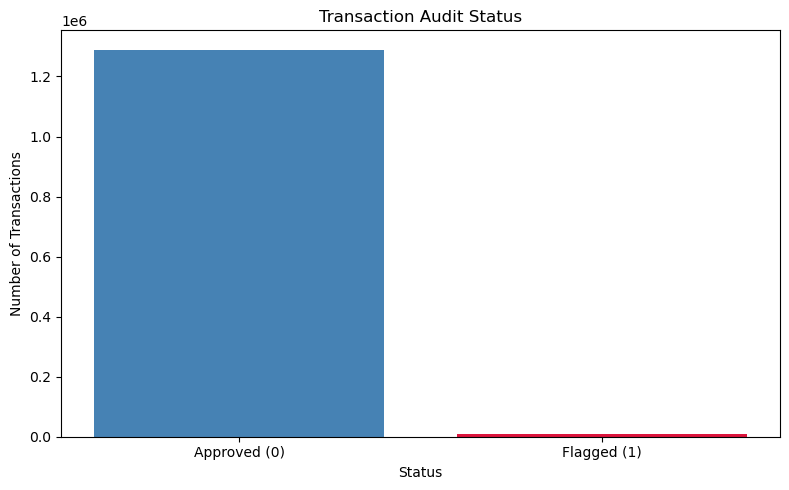

In [16]:
flagged_counts = df['flagged'].value_counts()
labels = ['Approved (0)', 'Flagged (1)']

plt.figure(figsize=(8, 5))
plt.bar(labels, flagged_counts.values, color=['steelblue', 'crimson'])
plt.title('Transaction Audit Status')
plt.ylabel('Number of Transactions')
plt.xlabel('Status')
plt.tight_layout()
plt.savefig('../notebooks/chart1_audit_status.png')
plt.show()

Chart 2 — Flagged transactions by category (Horizontal Bar)

C:\Users\rites\AppData\Local\Temp\ipykernel_18296\4218039604.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_data, x='incident_count', y='category', palette='Reds_r')


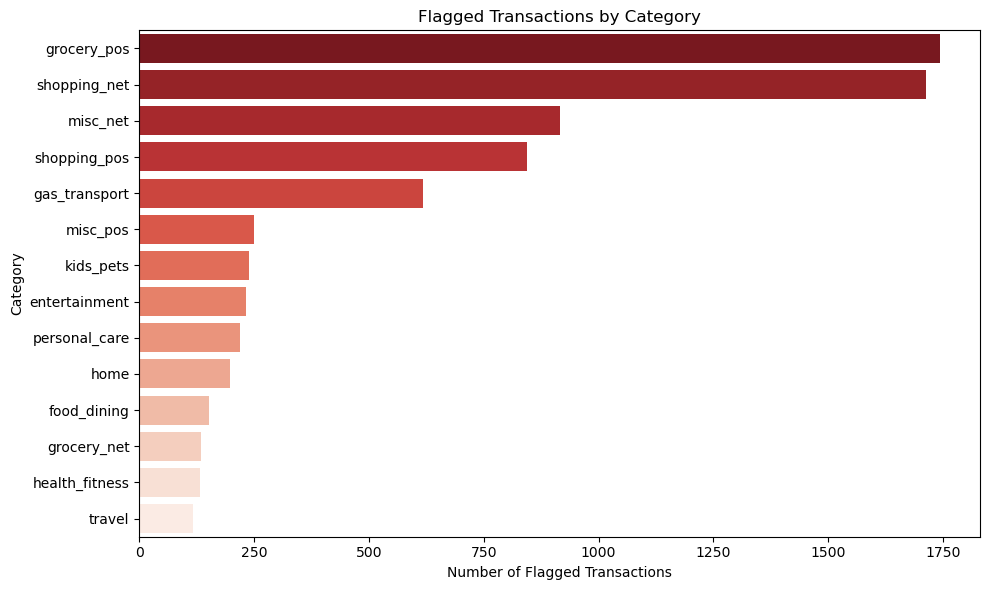

In [19]:
query = """
SELECT category, COUNT(*) as incident_count
FROM transactions
WHERE flagged = 1
GROUP BY category
ORDER BY incident_count DESC
"""
category_data = pd.read_sql_query(query, conn)

plt.figure(figsize=(10, 6))
sns.barplot(data=category_data, x='incident_count', y='category', palette='Reds_r')
plt.title('Flagged Transactions by Category')
plt.xlabel('Number of Flagged Transactions')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('../notebooks/chart2_category_risk.png')
plt.show()

Chart 3 — Transaction amount distribution (Histogram)

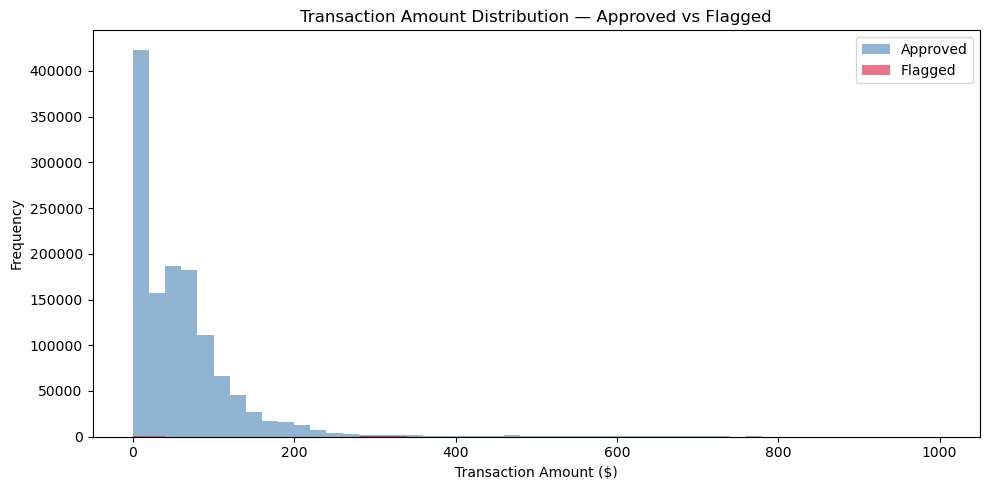

In [20]:
plt.figure(figsize=(10, 5))

plt.hist(df[df['flagged'] == 0]['amt'], bins=50, alpha=0.6, 
         color='steelblue', label='Approved', range=(0, 1000))
plt.hist(df[df['flagged'] == 1]['amt'], bins=50, alpha=0.6, 
         color='crimson', label='Flagged', range=(0, 1000))

plt.title('Transaction Amount Distribution — Approved vs Flagged')
plt.xlabel('Transaction Amount ($)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/chart3_amount_distribution.png')
plt.show()

Chart 4 — Fraud rate by hour of day

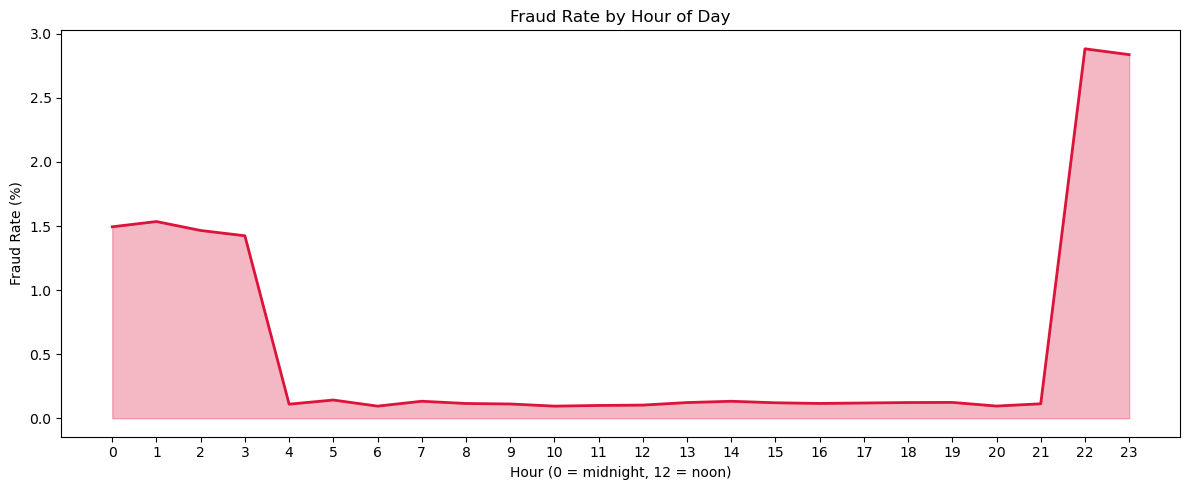

In [21]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_date_trans_time'].dt.hour

hourly_fraud = df.groupby('hour')['flagged'].mean() * 100

plt.figure(figsize=(12, 5))
plt.plot(hourly_fraud.index, hourly_fraud.values, color='crimson', linewidth=2)
plt.fill_between(hourly_fraud.index, hourly_fraud.values, alpha=0.3, color='crimson')
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour (0 = midnight, 12 = noon)')
plt.ylabel('Fraud Rate (%)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('../notebooks/chart4_hourly_fraud.png')
plt.show()

In [22]:
conn.close()
print("Connection closed")

Connection closed


# Phase 4 — Feature Engineering

Create a fresh DataFrame for modelling

In [23]:
df_model = df.copy()
print("Working copy created")
print(df_model.shape)

Working copy created
(1296675, 24)


Drop useless columns

In [24]:
cols_to_drop = [
    'Unnamed: 0',    # Just a leftover row index from the CSV
    'cc_num',        # Credit card number — personal info, useless for prediction
    'first',         # First name — personal info
    'last',          # Last name — personal info
    'street',        # Too specific, not useful as a pattern
    'zip',           # Too specific
    'trans_num',     # Transaction ID — unique per row, useless for patterns
    'unix_time',     # Duplicate of trans_date_trans_time in numeric form
    'dob',           # Date of birth — we will extract age instead
]

df_model = df_model.drop(columns=cols_to_drop)
print(f"Columns remaining: {df_model.shape[1]}")
print(df_model.columns.tolist())

Columns remaining: 15
['trans_date_trans_time', 'merchant', 'category', 'amt', 'gender', 'city', 'state', 'lat', 'long', 'city_pop', 'job', 'merch_lat', 'merch_long', 'flagged', 'hour']


Extract age from date of birth

In [25]:
from datetime import datetime

df_model['dob'] = pd.to_datetime(df['dob'])
df_model['age'] = df_model['dob'].apply(
    lambda x: (datetime.now() - x).days // 365
)
df_model = df_model.drop(columns=['dob'])

print(df_model['age'].describe())

count    1.296675e+06
mean     5.202757e+01
std      1.741197e+01
min      2.100000e+01
25%      3.900000e+01
50%      5.000000e+01
75%      6.300000e+01
max      1.010000e+02
Name: age, dtype: float64


Extract time features

In [26]:
df_model['trans_date_trans_time'] = pd.to_datetime(df_model['trans_date_trans_time'])
df_model['hour'] = df_model['trans_date_trans_time'].dt.hour
df_model['day_of_week'] = df_model['trans_date_trans_time'].dt.dayofweek
df_model['month'] = df_model['trans_date_trans_time'].dt.month

df_model = df_model.drop(columns=['trans_date_trans_time'])

print(df_model[['hour', 'day_of_week', 'month']].head())

   hour  day_of_week  month
0     0            1      1
1     0            1      1
2     0            1      1
3     0            1      1
4     0            1      1


Calculate distance between customer and merchant

In [27]:
import numpy as np

df_model['distance_km'] = np.sqrt(
    (df_model['lat'] - df_model['merch_lat'])**2 +
    (df_model['long'] - df_model['merch_long'])**2
) * 111

df_model = df_model.drop(columns=['lat', 'long', 'merch_lat', 'merch_long'])

print(df_model['distance_km'].describe())

count    1.296675e+06
mean     8.498838e+01
std      3.160708e+01
min      2.649159e-02
25%      6.271033e+01
50%      8.861253e+01
75%      1.085065e+02
max      1.568834e+02
Name: distance_km, dtype: float64


Encode categorical columns

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_model['merchant_encoded'] = le.fit_transform(df_model['merchant'])
df_model['category_encoded'] = le.fit_transform(df_model['category'])
df_model['gender_encoded'] = le.fit_transform(df_model['gender'])
df_model['state_encoded'] = le.fit_transform(df_model['state'])
df_model['city_encoded'] = le.fit_transform(df_model['city'])
df_model['job_encoded'] = le.fit_transform(df_model['job'])

df_model = df_model.drop(columns=['merchant', 'category', 'gender', 'state', 'city', 'job'])

print("Encoding complete")
print(df_model.dtypes)

Encoding complete
amt                 float64
city_pop              int64
flagged               int64
hour                  int32
age                   int64
day_of_week           int32
month                 int32
distance_km         float64
merchant_encoded      int32
category_encoded      int32
gender_encoded        int32
state_encoded         int32
city_encoded          int32
job_encoded           int32
dtype: object


Final check before modelling

In [29]:
print("Final shape:", df_model.shape)
print("\nAny missing values?")
print(df_model.isnull().sum().sum())
print("\nColumn list:")
print(df_model.columns.tolist())

Final shape: (1296675, 14)

Any missing values?
0

Column list:
['amt', 'city_pop', 'flagged', 'hour', 'age', 'day_of_week', 'month', 'distance_km', 'merchant_encoded', 'category_encoded', 'gender_encoded', 'state_encoded', 'city_encoded', 'job_encoded']
